# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 7</span>

### Exercise 07.1
In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.

### Exercise 07.2

Use the NSL simulator code to <span style="color:red">print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations</span> of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
<span style="color:red">Perform your MC and MD simulations by re-starting after such equilibration time.</span>

1. <span style="color:red">Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique

### Exercise 07.3

<span style="color:red">Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code</span>: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

### Exercise 07.4

By means of your upgraded NSL simulator code, equilibrate and <span style="color:red">perform MC NVT and MD NVE simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ... <span style="color:red"> and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.</span>

### Supplementary activity ... just for your fun!
Note that he following **is not** part of the Numerical Exercise 7; if you had fun with exercises 7.* and you are courious, you could try to repeat exercises 7.2 and 7.4 in the following different thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r^\star_c = 2.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r^\star_c = 5.0$)

## **Submission**

#### **What is MC simulation?**
We sample the transition probability for a real gas simulation using the Metropolis algorithm. Thanks to the variable `vec _delta` (the amount of displacement that a particle can make) with the function `void Particle :: translate(vec delta, vec side)` we execute a displacement in every direction sampled from a uniform distribution $\in [-\delta; \delta]$ of a randomly chosen particle. Then we calculate the total energy of the system before and after the displacement thus calculate the Boltzmann weight:
$\begin{equation}
    p_{acc} \propto e^{- \beta \Delta E}
    \tag{1}
\end{equation}
$
Thus if the energy of the system has decreased the move is $100\%$ accepted.

### **Exercise 07.1**

Tail corrections exist due to numerical reasons because when numerically calculating physical quantities we defined a cutoff radius: $r_{cut}$, which is a spherical cutoff of the potential energy. This however introduces an error, because it no longer represents the effective potential acting on the particles. We introduce $V_{tail}$ and $p_{tail}$ as corrections of this error. It is sensible to hypothise $g(r)=1$ for $r>r_{cut}$ which means that the probability of finding a particle at distance $r$ from another particle is certain. It is possible to write $<V>_{tail}$ as (in spherical coordinates):
$
\begin{equation}
    <V>_{tail} = 2\pi\rho N\int_{r_{cut}} ^\infty dr r^2 v(r) =  \frac{8\pi\rho_{LJ}\varepsilon}{9r_{c(LJ)}^9} - \frac{8\pi\rho_{LJ}\varepsilon}{3r_{c(LJ)}^3}
    \tag{2}
\end{equation}
$

Where $v(r)$ is the potential of interaction between 2 particles and we made use of the spherical simmetry of the problem. Finding $p_{tail}$ is an analogous procedure. 

Calculation of the tail corrections for potential energy, $U$, and pressure $P$. To implement $V_{tail}$ and $p_{tail}$ I wrote the following code in `void System ::initialize_properties()`:

- `_vtail = 8.0*M_PI*_rho*(1.0/(9.0*pow(_r_cut,9.0)) - 1.0/(3*pow(_r_cut, 3.0)));`
- `_ptail = 32.0*M_PI*_rho*(1.0/(9.0*pow(_r_cut,9.0)) - 1.0/(6.0*pow(_r_cut, 3.0)));`

### **Exercise 07.2**
#### **Correct $T_i$**
To find the correct initial temperature for the MD simulation I decided to run various simulation with different initial temperatures, waiting for the system to equilibrate and then measuring the final temperature of the system. I did this with 2 different precisions. The first time I started from $T_i = 1.0$ untile $T_i = 2.2$ incrementing each time $T_i$ by $0.1$. Then I tried to do a more precise sampling by sampling between $T_i \in [1.9; 2.2]$ and iterating each time by $0.01$.
For each temperature I ran the simulation for 100 blocks each of 10 steps and I saved in `DATA/finding_temp1.dat` and `finding_temp2.dat` the last value of the data blocking with the cumulative average and the it's error. 

The data for this initial simulation is stored in `DATA/finding_temp1.dat` and `DATA/finding_temp2.dat`
From these plots we can see that an adequate initial value for the temperature $T$ = 1.99. 

The code I wrote to find the correct initial temperature is the following:
```cpp
const string PATH_FINDING_TEMP = "../../DATA/finding_temp.dat";

int main(int argc, char *argv[])
{
  int nconf = 1;
  System SYS;
  
  ofstream out; 
  out.open(PATH_FINDING_TEMP);
  if(!out.is_open()) cout << "Errore: impossibile creare " << PATH_FINDING_TEMP << endl;
  out.close(); 

  double temperature = 1.9;

  while (temperature <= 2.2)
  {
    SYS.initialize();
    SYS.initialize_properties();
    
    // I introduced this function in exercise 6
    SYS.set_temp_and_restart(temperature);
    equilibrate(SYS);
    SYS.block_reset(0);
    
    for (int i = 0; i < SYS.get_nbl(); i++)
    { // loop sui blocchi
      for (int j = 0; j < SYS.get_nsteps(); j++)
      { // loop sugli step nel blocco
        SYS.step();
        SYS.measure();
      }
      SYS.averages(i + 1);
      SYS.block_reset(i + 1);
    }
    
    SYS.finalize(); // Chiude i file del blocco corrente
    
    // Saves the last temperature measured 
    save_data(SYS, temperature);
    
    temperature += 0.01;
  }
  return 0;
}
```

I am well aware that statistically I should have let the system equilibrate and then start saving the temperature for the system (because it doesn't make sense to execute the data blocking while the system is still evolving, even though it reaches the equilibrium in one block), however the aim for this part of the exercise was not to find a perfect exact value for $T_i$ but to find an initial value that could yield a final value for the temperature of $\approx T_f = 1.1$ (after some simulation I found that the correct initial temperature for having a final value of the temperature $T_f = 1.1$ in Verlet after equilibrium is $1.985$)

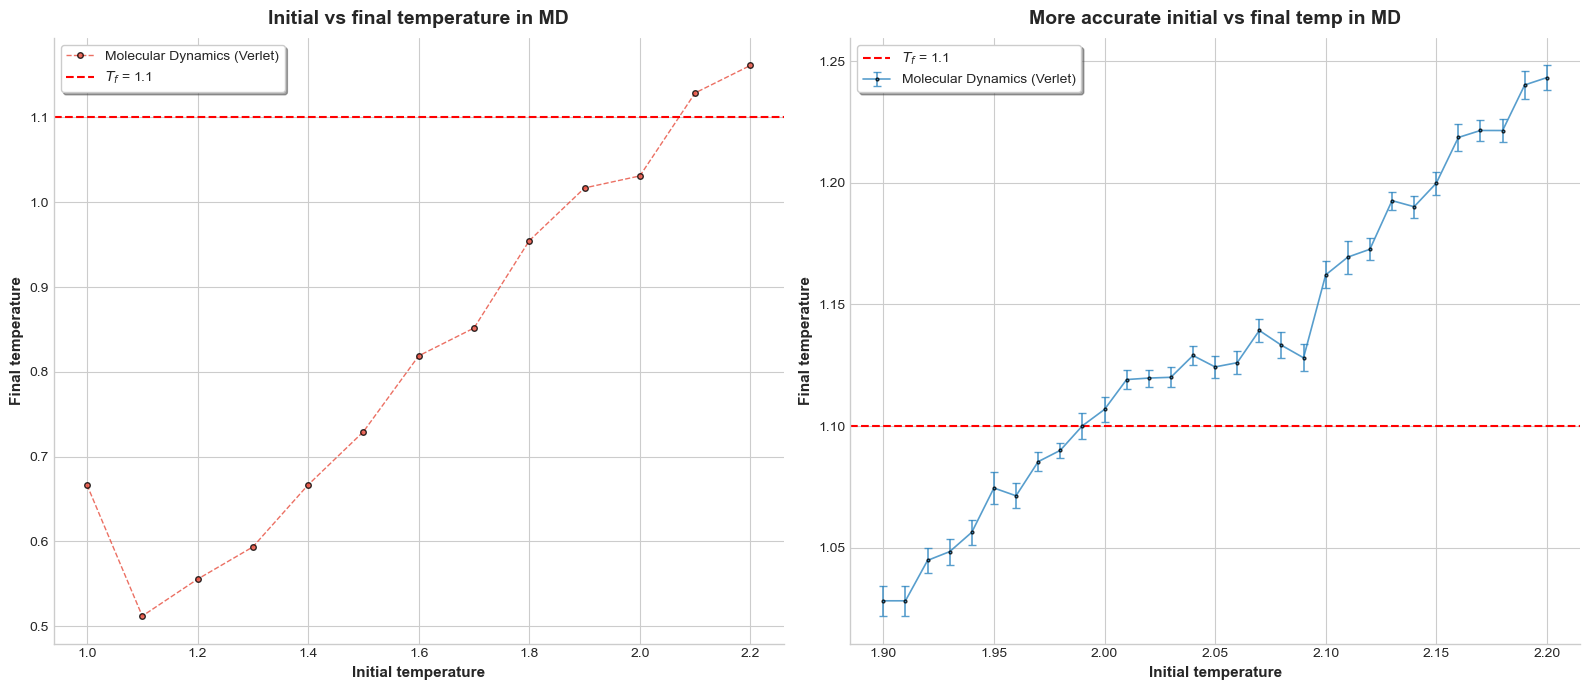

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Palette colori per distinguere i metodi
red = '#E74C3C'  # Rosso
blue = '#2E86C1'  # Blu

p_temp_1 = np.loadtxt('DATA/finding_temp1.dat')
p_temp_2 = np.loadtxt('DATA/finding_temp2.dat')

# 3. Creazione della seconda figura con 2 subplots affiancati (griglia 1x2)
fig2, axs2 = plt.subplots(1, 2, figsize=(16, 7))

# Funzione per plottare la Temperatura Finale in funzione di quella Iniziale
def plots_t_final(ax, data, color, label, title):
    # Dati: X = colonna 0 (Temp iniziale), Y = colonna 2 (Temp finale)
    ax.plot(data[:, 0], data[:, 3], 
            color=color, linestyle='--', linewidth=1.0, marker='o', markersize=4, 
            markeredgecolor='black', alpha=0.8, label=label)
    ax.axhline(y=1.1, color='red', linestyle='--', linewidth=1.5, label='$T_f$ = 1.1')
            
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Final temperature', fontsize=11, fontweight='bold')
    ax.set_xlabel('Initial temperature', fontsize=11, fontweight='bold')

def plots_t_final_precise(ax, data, color, label, title):
    # Dati: X = colonna 0 (Temp iniziale), Y = colonna 2 (Temp finale)
    ax.errorbar(data[:, 0], data[:, 3], yerr=data[:, 4], 
                color=color, ecolor=color, linestyle='-', linewidth=1.2, 
                marker='o', markersize=2, markeredgecolor='black', capsize=3, 
                alpha=0.8, label=label)
            
    ax.axhline(y=1.1, color='red', linestyle='--', linewidth=1.5, label='$T_f$ = 1.1')
            
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Final temperature', fontsize=11, fontweight='bold')
    ax.set_xlabel('Initial temperature', fontsize=11, fontweight='bold')

# Grafico a Sinistra: T iniziale vs T finale
plots_t_final(axs2[0], p_temp_1, red, 'Molecular Dynamics (Verlet)', 'Initial vs final temperature in MD')

# Grafico a Destra: T in funzione degli step (Con la linea rossa a 1.1)
plots_t_final_precise(axs2[1], p_temp_2, blue, 'Molecular Dynamics (Verlet)', 'More accurate initial vs final temp in MD')

# Personalizzazione comune per i subplot della seconda figura
for ax in axs2.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, shadow=True, fontsize=10, loc='best')

# 4. Ottimizzazione layout e salvataggio
plt.tight_layout()
plt.savefig('IMAGES/finding_temperature_plot.png', dpi=300, bbox_inches='tight')
plt.show()

#### **Acceptance of $50\%$**

In order to find the correct value to have an acceptance rate of 50% for the Metropolis sampling I used trial and error, trying to gradually reach the desidered acceptance rate. I found that with $dt^\star$ = 0.102 the acceptance rate for a simulation of $N_{blocks}$ = 50 of $N_{steps}$ = 10 each ($T$ = 1.1) is $\langle A \rangle$ = 0.5009 $\pm$ 0.0176.


In [3]:
data = np.loadtxt('DATA/acceptance.dat')
values = data[:,1]

average = np.mean(values)
std_dev = np.std(values)

valori = data[:, 1]

print(f"Results for 'acceptance.dat':")
print(f"Average: {average:.4f}")
print(f"Standard deviation: {std_dev:.4f}")

Results for 'acceptance.dat':
Average: 0.5009
Standard deviation: 0.0176


#### **Potential energy for $5\cdot10^5$ steps**
After having determined the correct timestep and initial temperature that guaranteed the MC sampling to have a $50\%$ acceptance rate and the MD simulation to have a temperature after equilibration of $T^\star$, I then saved the potential energy values for $5\cdot10^5$ steps for both the MC and MD simulation after equilibrating the system over $1000$ steps. Below I show the calculated values of the potential energy as a function of the time steps. 

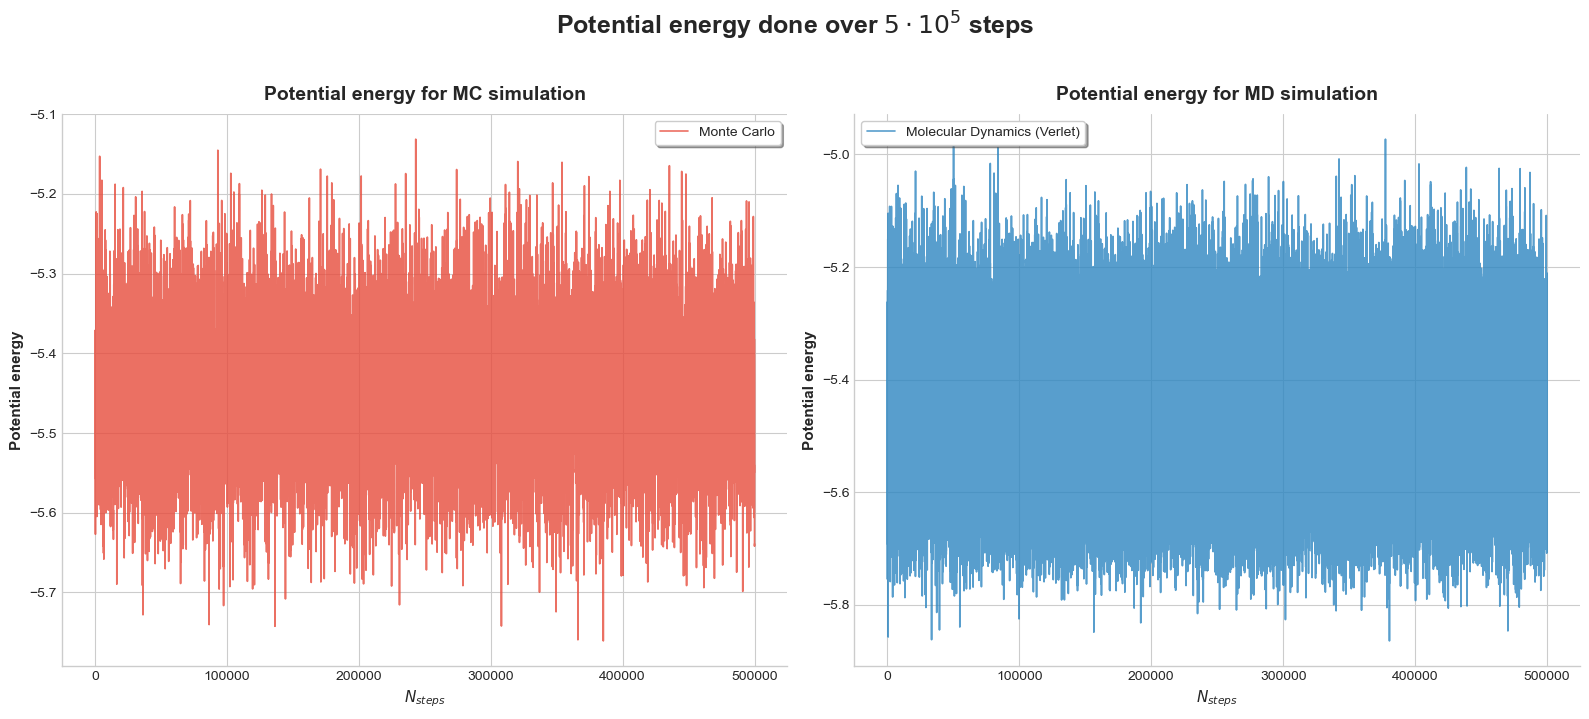

In [9]:
p_MC = np.loadtxt('DATA/p_energyMD.dat')
p_MD = np.loadtxt('DATA/p_energyMC.dat')

# 3. Creazione della prima figura con 2 subplots affiancati (griglia 1x2)
fig1, axs1 = plt.subplots(1, 2, figsize=(16, 7))

# Funzione di supporto per plottare i dati dell'energia potenziale
def plots(ax, data, color, label, title):
    # Dati: X = colonna 0 (Steps), Y = colonna 1 (Energia)
    ax.plot(data[:, 0], data[:, 1], 
            color=color, linestyle='-', linewidth=1.2, markersize=4, 
            markeredgecolor='black', alpha=0.8, label=label)
    
    # Formattazione titoli e assi
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Potential energy', fontsize=11, fontweight='bold')
    ax.set_xlabel('$N_{steps}$', fontsize=11, fontweight='bold')

# Grafico a Sinistra: Energia Interna MC
plots(axs1[0], p_MC, red, 'Monte Carlo', 'Potential energy for MC simulation')

# Grafico a Destra: Energia Interna MD
plots(axs1[1], p_MD, blue, 'Molecular Dynamics (Verlet)', 'Potential energy for MD simulation')

# Personalizzazione comune per i subplot della prima figura
for ax in axs1.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, shadow=True, fontsize=10, loc='best')

# Titolo globale
fig1.suptitle('Potential energy done over $5 \cdot 10^5$ steps', 
              fontsize=18, fontweight='bold', y=1.02)

# 4. Ottimizzazione layout e salvataggio
plt.tight_layout()
plt.savefig('IMAGES/potenzialMC&MD.png', dpi=300, bbox_inches='tight')
plt.show()

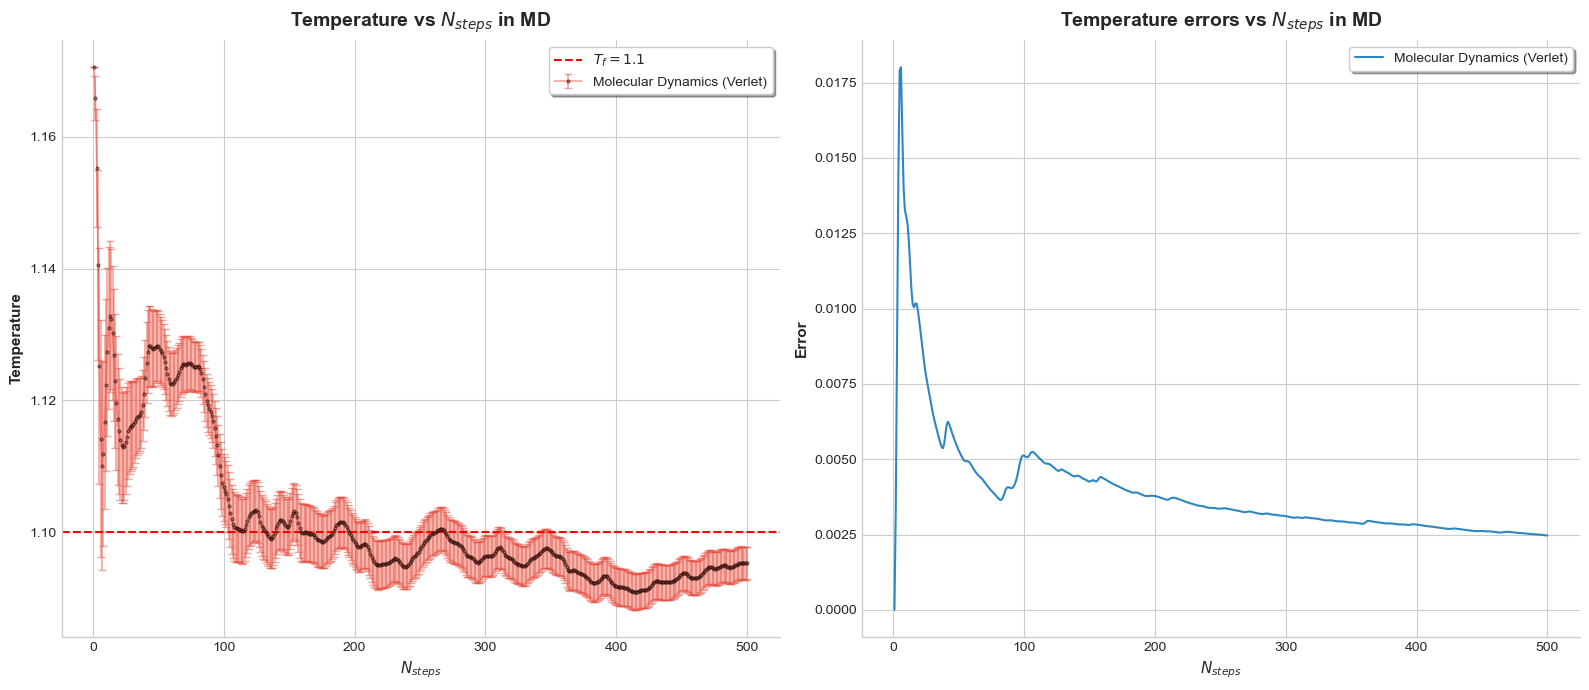

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# (Assicurati di avere definito prima i colori se non sono nel blocco corrente)
color_gibbs = '#E74C3C'  # Rosso
color_metro = '#2E86C1'  # Blu

p_temp_1 = np.loadtxt('DATA/temperature.dat')

# 3. Creazione della seconda figura con 2 subplots affiancati (griglia 1x2)
fig2, axs2 = plt.subplots(1, 2, figsize=(16, 7))
    
# Funzione per plottare la Temperatura in funzione degli step (MD) CON ERRORI
def plots_t_MD_values(ax, data, color, label, title):
    # Dati: X = colonna 0 (Steps), Y = colonna 2 (Temperatura), Y_err = colonna 3 (Errori)
    # Usiamo errorbar invece di plot per aggiungere le barre di errore.
    # marker='o' rende ben visibile ogni singolo punto misurato.
    ax.errorbar(data[:, 0], data[:, 2], yerr=data[:, 3], 
                color=color, ecolor=color, linestyle='-', linewidth=1.2, 
                marker='o', markersize=2, markeredgecolor='black', capsize=3, 
                alpha=0.5, label=label)
            
    # ---> AGGIUNTA DELLA LINEA TRATTEGGIATA ROSSA a Y = 1.1 <---
    ax.axhline(y=1.1, color='red', linestyle='--', linewidth=1.5, label='$T_f = 1.1$')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Temperature', fontsize=11, fontweight='bold')
    ax.set_xlabel('$N_{steps}$', fontsize=11, fontweight='bold')

def plots_t_MD_error(ax, data, color, label, title):
    # Dati: X = colonna 0 (Steps), Y = colonna 3 (Temperatura - Errore)
    # Aggiungiamo marker='o' anche qui per far risaltare i punti
    ax.plot(data[:, 0], data[:, 3], 
            color=color, linestyle='-', 
            alpha=1, label=label)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Error', fontsize=11, fontweight='bold') # Ho cambiato l'etichetta in 'Error'
    ax.set_xlabel('$N_{steps}$', fontsize=11, fontweight='bold')

# Grafico a Sinistra: Valori Temperatura con barre di errore
plots_t_MD_values(axs2[0], p_temp_1, color_gibbs, 'Molecular Dynamics (Verlet)', 'Temperature vs $N_{steps}$ in MD')

# Grafico a Destra: Valori degli errori
plots_t_MD_error(axs2[1], p_temp_1, color_metro, 'Molecular Dynamics (Verlet)', 'Temperature errors vs $N_{steps}$ in MD')

# Personalizzazione comune per i subplot della seconda figura
for ax in axs2.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=True, shadow=True, fontsize=10, loc='best')

# 4. Ottimizzazione layout e salvataggio
plt.tight_layout()
plt.savefig('IMAGES/trial_temperature_plot.png', dpi=300, bbox_inches='tight')
plt.show()

We can see that the value found for the initial temperature gives a simulation that has a final $T^{\star}$ that is compatible with the desidered final temperature value. It is also possible to observe that the data blocking error trend of $1/\sqrt{N}$. These are the plots of the data blocking for the temperature after equilibration of $1000$ steps. Over $500$ blocks of $10$ steps each. The data is all present in the directory `DATA` where there are the directories where are present the files:
- for finding the correct initial temperature: `finding_temp*.dat`
- verifying the acceptance rate: `acceptance.dat`
- temperature after equilibration of $1000$ steps: `temperature.dat`
- potential energy values without equilibrating the system before: `p_energyMC_no_eq_.dat`, `p_energyMD_no_eq_.dat`
- potential energy values after equilibrating the system: `p_energyMC.dat`, `p_energyMD.dat`


#### **Auto-correlation**
The **autocorrelation function** represents a way in stochastic simulation to measure the dependence between an observable of the system $f(x(t))$ at time $t$ and after a **lag** $\tau$.

$$Ac_f(\tau) = \frac{\langle f(t) f(t+\tau) \rangle - \langle f \rangle^2}{\langle f^2 \rangle - \langle f \rangle^2} = \frac{\text{cov}[f(t), f(t+\tau)]}{\text{var}[f(t)]}$$

- **$Ac_f(0) = 1$**: Perfect correlation at zero time lag.
- **$Ac_f(\tau) \to 0$ as $\tau \to \infty$**: Complete loss of memory / statistical independence.

---
1. **Memory &amp; Correlation Time ($\tau_c$)**:
   - The autocorrelation decays exponentially at long lags:
     $$Ac_f(\tau) \sim e^{-\tau / \tau_c}$$
   - $\tau_c$ represents the characteristic **correlation time**, describing how long the system takes to move to a state significantly different from its initial one.

2. **Impact on Monte Carlo Sampling**:
   - Consecutive steps in a Markov chain are strongly correlated ($Ac_f(\tau) \approx 1$ for small $\tau$) 
   - If a simulation runs for total time $t_{\text{max}}$, the number of **statistically independent** measurements $n$ is not the total sample count, but approximately:
     $$n \approx \frac{t_{\text{max}}}{2\tau_c}$$
   - Calculating sample variance naively on raw correlated steps severely underestimates the true statistical error of the mean.

It is useful to use datablocking in order to:
   - To eliminate correlation bias without discarding steps, data points are grouped into blocks of length $L \gg \tau_c$ .
   - Block averages become uncorrelated, satisfying the Central Limit Theorem and yielding reliable error estimates.



Caricamento dati...
Calcolo autocorrelazione...
Calcolo del fit esponenziale...
Fit lag for MC simulation = 15.658791
Fit lag for MC simulation = 27.434459


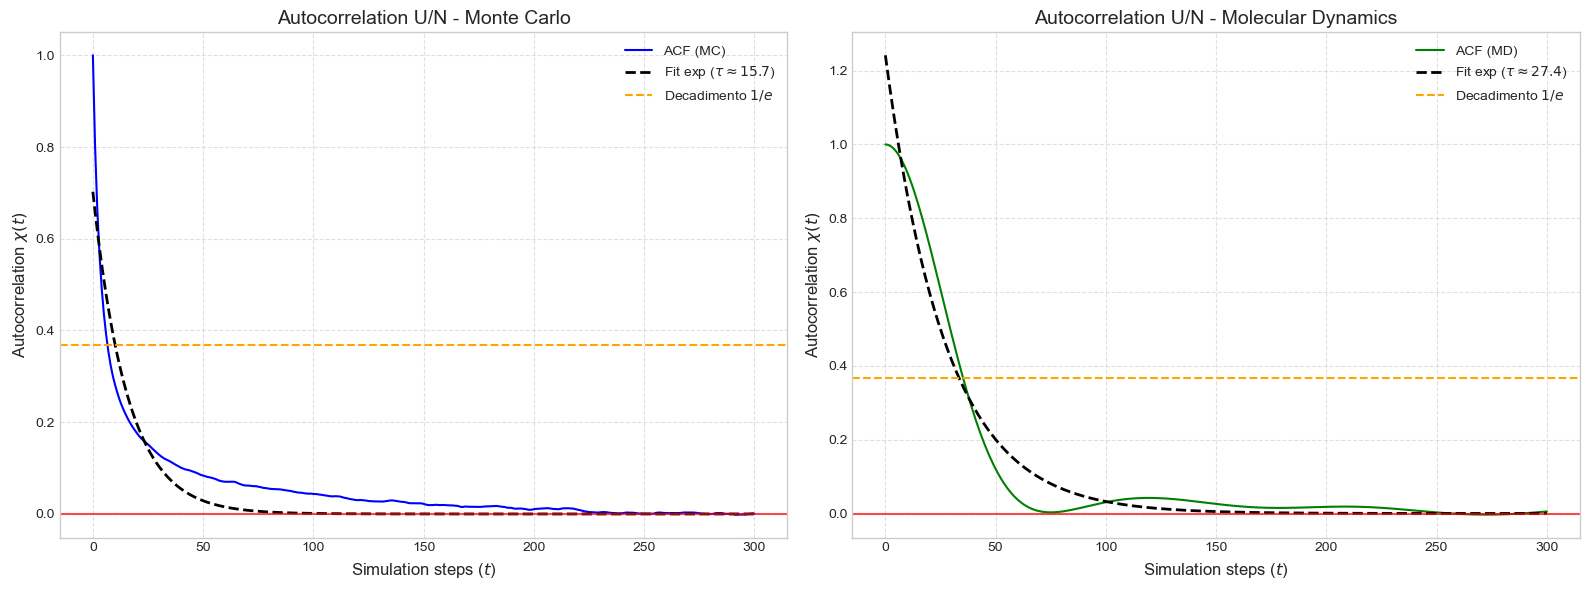

In [18]:

from statsmodels.tsa.stattools import acf
from scipy.optimize import curve_fit

file_mc = "DATA/p_energyMC.dat"
file_md = "DATA/p_energyMD.dat"

max_lag = 300 

def esponenziale(t, A, tau):
    return A * np.exp(-t / tau)

# Funzione di supporto per caricare i dati in modo sicuro
def load_data(filename):
    try:
        return np.loadtxt(filename, usecols=1)
    except OSError:
        print(f"ATTENZIONE: File '{filename}' non trovato nella cartella.")
        print("Verranno generati dati fittizi per farti testare lo script...")
        np.random.seed(42)
        data = np.zeros(50000) # Ridotto per velocità di test
        for i in range(1, 50000):
            data[i] = 0.995 * data[i-1] + np.random.normal()
        return data

# Imposta uno stile visivo pulito
plt.style.use('seaborn-v0_8-whitegrid')
print("Caricamento dati...")
data_mc = load_data(file_mc)
data_md = load_data(file_md)

print("Calcolo autocorrelazione...")
acf_mc = acf(data_mc, nlags=max_lag, fft=True)
acf_md = acf(data_md, nlags=max_lag, fft=True)

t_steps = np.arange(max_lag + 1)

print("Calcolo del fit esponenziale...")
# p0 è l'ipotesi iniziale per i parametri [A, tau]
try:
    popt_mc, _ = curve_fit(esponenziale, t_steps, acf_mc, p0=(1.0, 10.0))
    fit_mc = esponenziale(t_steps, *popt_mc)
    tau_mc = popt_mc[1]
except RuntimeError:
    print("Fit per Monte Carlo fallito.")
    fit_mc, tau_mc = np.zeros_like(t_steps), 0

try:
    popt_md, _ = curve_fit(esponenziale, t_steps, acf_md, p0=(1.0, 10.0))
    fit_md = esponenziale(t_steps, *popt_md)
    tau_md = popt_md[1]
except RuntimeError:
    print("Fit per Molecular Dynamics fallito.")
    fit_md, tau_md = np.zeros_like(t_steps), 0
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafico 1: Monte Carlo (Sinistra) ---
ax1.plot(t_steps, acf_mc, color='blue', label='ACF (MC)')
ax1.plot(t_steps, fit_mc, color='black', linestyle='--', linewidth=2, 
         label=f'Fit exp ($\\tau \\approx {tau_mc:.1f}$)')
ax1.axhline(0, color='red', linestyle='-', alpha=0.7)
ax1.axhline(np.exp(-1), color='orange', linestyle='--', label='Decadimento $1/e$')

ax1.set_title('Autocorrelation U/N - Monte Carlo', fontsize=14)
ax1.set_xlabel('Simulation steps ($t$)', fontsize=12)
ax1.set_ylabel(r'Autocorrelation $\chi(t)$', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- Grafico 2: Molecular Dynamics (Destra) ---
ax2.plot(t_steps, acf_md, color='green', label='ACF (MD)')
ax2.plot(t_steps, fit_md, color='black', linestyle='--', linewidth=2, 
         label=f'Fit exp ($\\tau \\approx {tau_md:.1f}$)')
ax2.axhline(0, color='red', linestyle='-', alpha=0.7)
ax2.axhline(np.exp(-1), color='orange', linestyle='--', label='Decadimento $1/e$')

ax2.set_title('Autocorrelation U/N - Molecular Dynamics', fontsize=14)
ax2.set_xlabel('Simulation steps ($t$)', fontsize=12)
ax2.set_ylabel(r'Autocorrelation $\chi(t)$', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()
plt.tight_layout()

print(f"Fit lag for MC simulation = {tau_mc:4f}" )
print(f"Fit lag for MC simulation = {tau_md:4f}" )
import os
os.makedirs('IMAGES', exist_ok=True)
plt.savefig('IMAGES/correlation.png', dpi=300, bbox_inches='tight')
plt.show()

Using a $\tau_{max} = 300$ the two FITs yield a characteristic correlation time $\tau_c = 15.7; 27.4$ respectively for NVT and NVE (or MC and MD simulations). To avoid underestimating the statistic error on datablocking, we know that we have to use $L>>\tau_c$ for the blocks, in order include in the blocks data of states different from each other. The risk of using a block that doesn't satisfy this property would be to use data of highly correlated states and therefore not actually independent information of the system. It is necessary to use blocks of length $L\geq 500$.

Calcolo degli errori per Monte Carlo...
Calcolo degli errori per Molecular Dynamics...


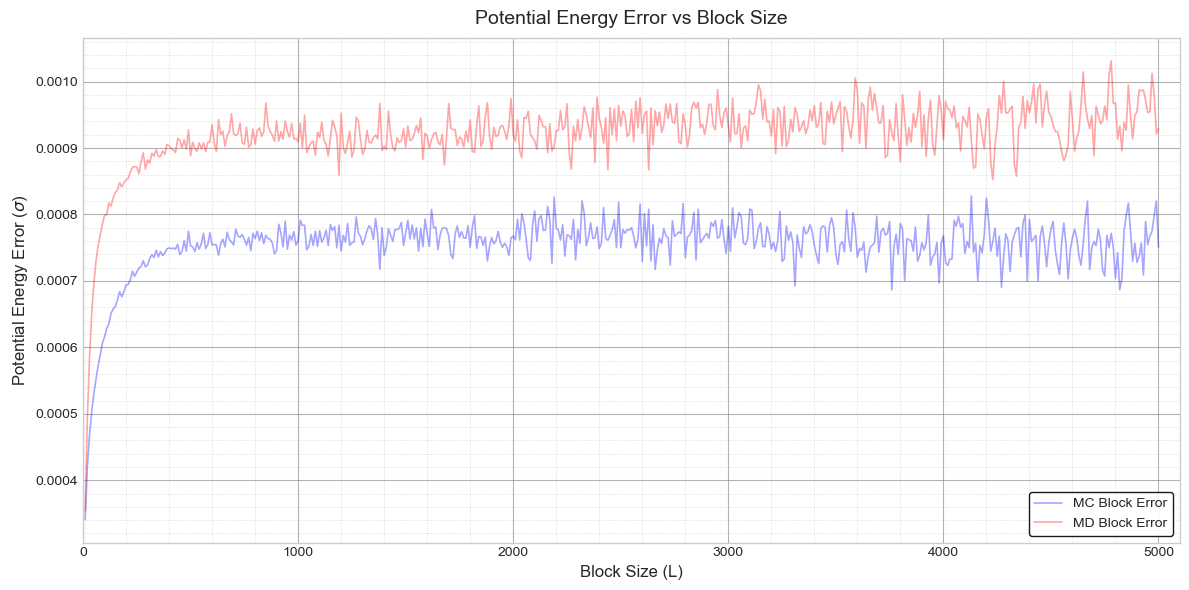

In [23]:
import pandas as pd
from matplotlib.ticker import MultipleLocator
import os

file_mc = "DATA/p_energyMC.dat"
file_md = "DATA/p_energyMD.dat"

def load_real_data(filename):
    try:
        # Assumiamo che il valore di interesse sia nella seconda colonna (indice 1)
        return np.loadtxt(filename, usecols=1)
    except OSError:
        raise FileNotFoundError(f"Errore: Il file '{filename}' non è stato trovato. Assicurati di lanciare lo script dalla cartella corretta.")

data_mc = load_real_data(file_mc)
data_md = load_real_data(file_md)

L_min = 10
L_max = 5000
# Calcoliamo l'errore per vari valori di L (step di 10 per avere un grafico denso come nell'immagine)
L_values = np.arange(L_min, L_max + 1, 10)

def calculate_blocking_error(data, L_vals):
    M = len(data)
    errors = []
    for L in L_vals:
        N = M // L  # Numero di blocchi
        if N <= 1:
            errors.append(np.nan)
            continue
        
        # Tronca i dati in eccesso
        truncated_data = data[:N*L]
        # Calcola le medie di ogni blocco
        block_means = np.mean(truncated_data.reshape(N, L), axis=1)
        
        # Calcola l'errore statistico (deviazione standard della media)
        global_mean = np.mean(block_means)
        global_mean_sq = np.mean(block_means**2)
        err = np.sqrt(np.abs(global_mean_sq - global_mean**2) / (N - 1))
        errors.append(err)
        
    return np.array(errors)

print("Calcolo degli errori per Monte Carlo...")
errors_mc = calculate_blocking_error(data_mc, L_values)

print("Calcolo degli errori per Molecular Dynamics...")
errors_md = calculate_blocking_error(data_md, L_values)

series_mc = pd.Series(errors_mc, index=L_values)
series_md = pd.Series(errors_md, index=L_values)

window_size = 20
moving_avg_mc = series_mc.rolling(window=window_size, min_periods=1).mean()
moving_avg_md = series_md.rolling(window=window_size, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(12, 6))

# A) Dati "grezzi" del data blocking (linee sottili e semi-trasparenti)
ax.plot(L_values, errors_mc, color='blue', linewidth=1.2, alpha=0.35, label='MC Block Error')
ax.plot(L_values, errors_md, color='red', linewidth=1.2, alpha=0.35, label='MD Block Error')

# C) Titoli ed etichette
ax.set_title("Potential Energy Error vs Block Size", fontsize=14, pad=10)
ax.set_xlabel("Block Size (L)", fontsize=12)
ax.set_ylabel(r"Potential Energy Error ($\sigma$)", fontsize=12)

# D) Formattazione degli assi
ax.set_xlim(0, L_max + 100)
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(200))
ax.yaxis.set_minor_locator(MultipleLocator((ax.get_yticks()[1] - ax.get_yticks()[0]) / 5))

# E) Griglia (stile simile al riferimento)
ax.grid(which='major', linestyle='-', linewidth=0.8, color='gray', alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.4)

# F) Legenda in basso a destra
ax.legend(loc='lower right', fontsize=10, frameon=True, edgecolor='black', facecolor='white', framealpha=0.9)

plt.tight_layout()

# Salvataggio e visualizzazione
os.makedirs('IMAGES', exist_ok=True)
plt.savefig('IMAGES/potential_energy_error_vs_blocksize.png', dpi=300, bbox_inches='tight')
plt.show()

It is possible to see that the errors on the data blocking grow increasingly with the size of the block untill reaching a plateau. Which means that the correlation is present untill reaching values of $L>600$ where the values of the errors on the blocks for both simulation types reach a maximum value.

### **Exercize 7.3 - Calculation of $g(r)$**
$g(r)$ measures the local average density of particles at a distance $r$ from a reference particle, normalized relative to the density of an ideal gas (an ideal, non-interacting uniform distribution):

$$g(r) = \frac{1}{\rho N \Delta V(r)} \left\langle \sum_{i \neq j} \delta_{r \le |r_i - r_j| < r + dr} \right\rangle$$

Where:
* $\rho = \frac{N}{V}$ is the average number density.
* $\Delta V(r) = \frac{4}{3} \pi \left[ (r + dr)^3 - r^3 \right]$ is the volume of the spherical shell of thickness $dr$.

**Key behaviors:**
* $g(r) \to 0$ for $r < \sigma$: Excluded volume effect (short-range repulsion between atoms).
* $g(r) \to 1$ as $r \to \infty$: Loss of spatial correlation at long distances (the fluid recovers homogeneity).

---

The shape of $g(r)$ uniquely characterizes the state of aggregation of the system:

1. **Ideal Gas:** $g(r) = 1$ for all $r > 0$ (complete absence of spatial correlations).
2. **Liquid:** Exhibits damped oscillations. The prominent first peak represents the first solvation shell; subsequent peaks decay rapidly toward $1$.
3. **Crystalline Solid:** Features sharp, discrete, and persistent peaks extending over long distances, reflecting long-range structural order.

---


**Sampling in Simulation (MC / MD)**
* Discretize the distance domain into a histogram with bin width $dr$.
* For each sampled configuration, calculate the distance $r_{ij} = |r_i - r_j|$ for every pair $i \neq j$.
* If $r_{ij}$ falls in $[r, r + dr]$, increment the corresponding bin counter by $2$ due to symmetric counting for pair $ij$ and $ji$.
* At the end of the simulation, normalize the histogram by dividing each bin value by $\rho N \Delta V(r)$.



To calculate $g(r)$ I added a part of code to the function `void System:: measure()` by writing:
```cpp
//...
  if (_measure_penergy or _measure_pressure or _measure_gofr)
  {
    for (int i = 0; i < _npart - 1; i++)
    {
      for (int j = i + 1; j < _npart; j++)
      {
        distance(0) = this->pbc(_particle(i).getposition(0, true) - _particle(j).getposition(0, true), 0);
        distance(1) = this->pbc(_particle(i).getposition(1, true) - _particle(j).getposition(1, true), 1);
        distance(2) = this->pbc(_particle(i).getposition(2, true) - _particle(j).getposition(2, true), 2);
        dr = sqrt(dot(distance, distance));
        // GOFR
        if (_measure_gofr)
        {
          int j = (int)(dr / _bin_size);
          if (j >= 0 && j < _n_bins)
          {
            _measurement(_index_gofr + j) = _measurement(_index_gofr + j) + 2;
          }
        }
        if (dr < _r_cut)
        {
          if (_measure_penergy)
            penergy_temp += 1.0 / pow(dr, 12) - 1.0 / pow(dr, 6); // POTENTIAL ENERGY
          if (_measure_pressure)
            virial += 1.0 / pow(dr, 12) - 0.5 / pow(dr, 6); // PRESSURE
        }
      }
    }
  }
  //...
```
After filling the hystogram it is necessary to normalize, which I do in `void System :: averages()` where I wrote the following code:
```cpp 
  // GOFR //////////////////////////////////////////////////////////////////////
  if (_measure_gofr)
  {
    coutf.open("../OUTPUT/GOFR/gofr" + to_string(blk) + ".dat", ios::app);
    coutf << endl;
    for (int i = 0; i < _n_bins; i++)
    {
      _gofr_volume = 4.0 * M_PI / 3.0 * (pow(_bin_size * (i + 1), 3) - pow(_bin_size * i, 3));
      _gofr_norm = _rho * double(_npart) * _gofr_volume;

      average = _average(_index_gofr + i) / _gofr_norm;
      sum_average = _global_av(_index_gofr + i) / _gofr_norm;
      sum_ave2 = _global_av2(_index_gofr + i) / (_gofr_norm * _gofr_norm);
      coutf << setw(12) << (i + 0.5) * _bin_size
            << setw(12) << average
            << setw(12) << sum_average / double(blk)
            << setw(12) << this->error(sum_average, sum_ave2, blk) << endl;
    }

    coutf.close();
  }
```

### **Exercise 7.4 - $g(r)$ sampling**
By means of your upgraded NSL simulator code, equilibrate and <span style="color:red">perform MC NVT and MD NVE simulations via a Lennard-Jones model</span> of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)
---
Below I show the plots for potential energy per particle and pressure per particle. To do these calculations I let the system equilibrate for $10^4$ steps and then calculated the values for $N_{blocks} = 100$ each of $N_{step} = 1000$. For the MD simulation I started the simulation for a $T_i = 1.985$ because I saw that after equilibrating it gave a final value of the temperature $T_f$ more compatible to $1.1$. To measure $g(r)$ I used 100 bins. 



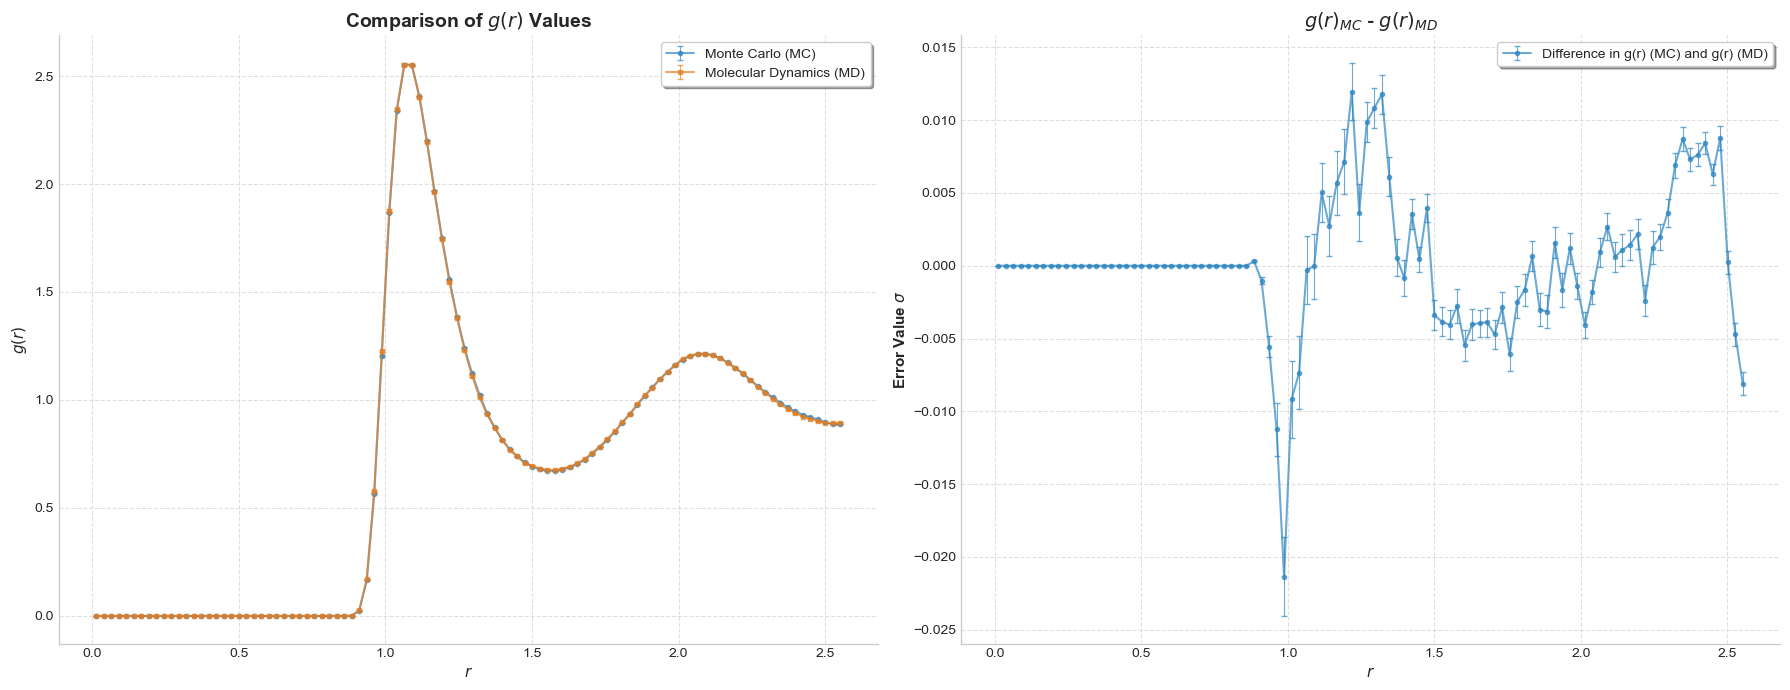

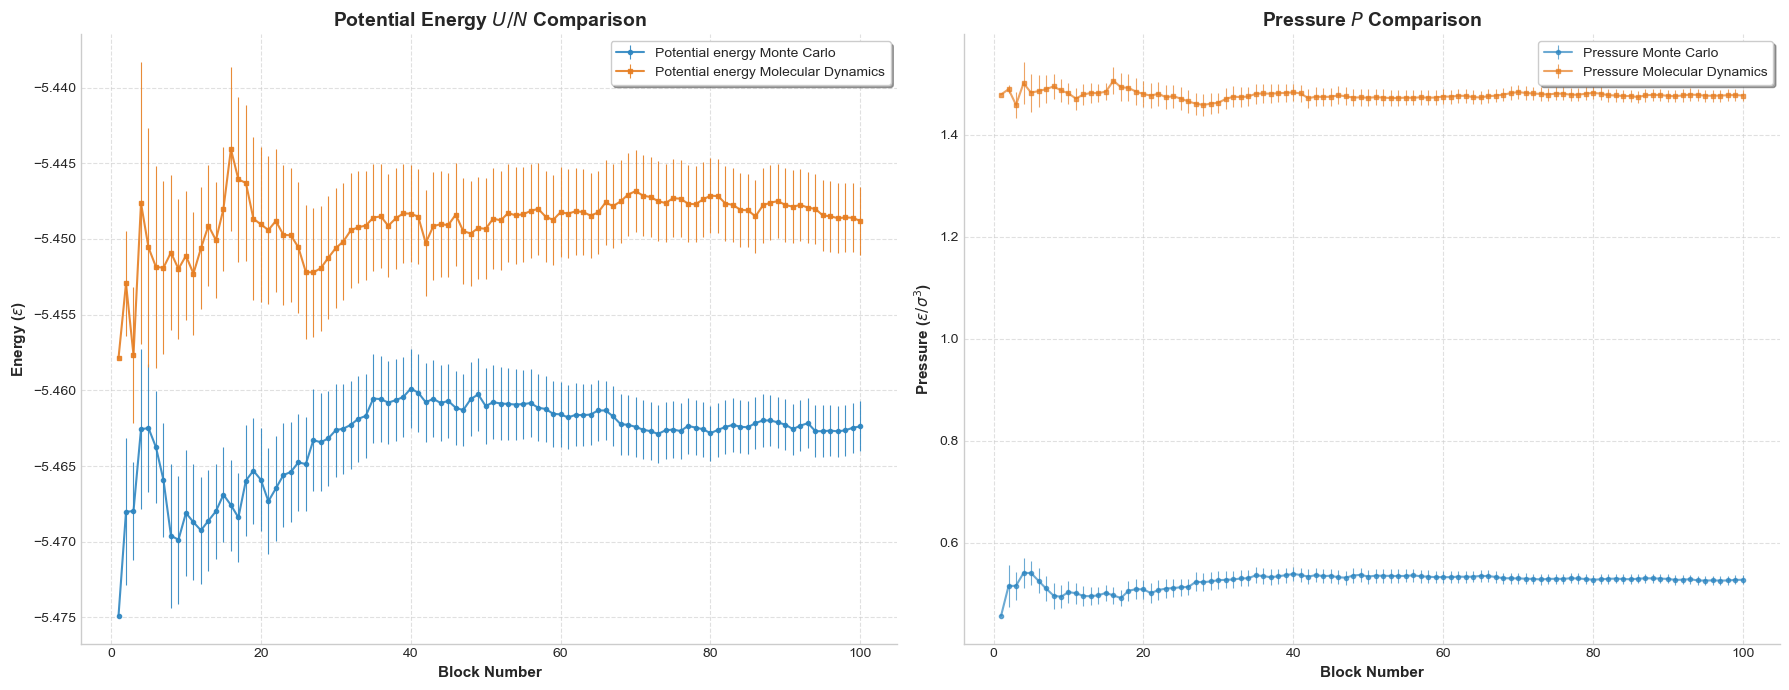

In [34]:

path = 'DATA/DATA.5/'

data_mc = np.loadtxt(path + 'gofr100MC.dat')
data_md = np.loadtxt(path + 'gofr100MD.dat')

# Estrazione colonne: 0=r, 2=g(r), 3=errore
x_mc, y_mc, err_mc = data_mc[:, 0], data_mc[:, 2], data_mc[:, 3]
x_md, y_md, err_md = data_md[:, 0], data_md[:, 2], data_md[:, 3]

# ==============================================================================
# GENERAZIONE SUBPLOTS AFFIANCATI
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1 (SINISTRA): g(r) sovrapposti ---
ax1.errorbar(x_mc, y_mc, yerr=err_mc, color='#2E86C1', label='Monte Carlo (MC)', 
             alpha=0.7, marker='o', markersize=3, elinewidth=0.8, capsize=2)
ax1.errorbar(x_md, y_md, yerr=err_md, color='#E67E22', label='Molecular Dynamics (MD)', 
             alpha=0.7, marker='s', markersize=3, elinewidth=0.8, capsize=2)

ax1.set_title('Comparison of $g(r)$ Values', fontsize=14, fontweight='bold')
ax1.set_xlabel('$r$', fontsize=11, fontweight='bold')
ax1.set_ylabel('$g(r)$', fontsize=11, fontweight='bold')
ax1.legend(frameon=True, shadow=True)

# --- PLOT 2 (DESTRA): Errori sovrapposti ---
ax2.errorbar(x_mc, y_mc-y_md, yerr=err_mc, color='#2E86C1', label='Difference in g(r) (MC) and g(r) (MD)', 
             alpha=0.7, linestyle='-', marker='o', markersize=3, elinewidth=0.8, capsize=2)

ax2.set_title('$g(r)_{MC}$ - $g(r)_{MD}$', fontsize=14, fontweight='bold')
ax2.set_xlabel('$r$', fontsize=11, fontweight='bold')
ax2.set_ylabel('Error Value $\sigma$', fontsize=11, fontweight='bold')
ax2.legend(frameon=True, shadow=True)

# Estetica comune (rimozione bordi superflui e griglia)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('IMAGES/mc_md_double_comparison.png', dpi=300)
plt.show()

# ==============================================================================
# CARICAMENTO DATI (Energia Potenziale e Pressione)
# ==============================================================================
# Percorso della cartella
path = 'DATA/DATA.5/'

# Caricamento Energia Potenziale
epot_mc = np.loadtxt(path + 'potential_energyMC.dat')
epot_md = np.loadtxt(path + 'potential_energyMD.dat')

# Caricamento Pressione
pres_mc = np.loadtxt(path + 'pressureMC.dat')
pres_md = np.loadtxt(path + 'pressureMD.dat')

# Definizione colonne (0=blocco, 2=valore, 3=errore)
# Assumo la struttura standard dell'esercitazione
blk_mc = epot_mc[:, 0]
val_epot_mc, err_epot_mc = epot_mc[:, 2], epot_mc[:, 3]
val_epot_md, err_epot_md = epot_md[:, 2], epot_md[:, 3]

val_pres_mc, err_pres_mc = pres_mc[:, 2], pres_mc[:, 3]
val_pres_md, err_pres_md = pres_md[:, 2], pres_md[:, 3]

# ==============================================================================
# GENERAZIONE GRAFICI
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1 (SINISTRA): Potential Energy ---
ax1.errorbar(blk_mc, val_epot_mc, yerr=err_epot_mc, color='#2E86C1', 
             label='Potential energy Monte Carlo', alpha=0.9, fmt='-o', markersize=3, elinewidth=0.8)
ax1.errorbar(blk_mc, val_epot_md, yerr=err_epot_md, color='#E67E22', 
             label='Potential energy Molecular Dynamics', alpha=0.9, fmt='-s', markersize=3, elinewidth=0.8)

ax1.set_title('Potential Energy $U/N$ Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Block Number', fontsize=11, fontweight='bold')
ax1.set_ylabel('Energy ($\epsilon$)', fontsize=11, fontweight='bold')
ax1.legend(frameon=True, shadow=True)

# --- PLOT 2 (DESTRA): Pressure ---
ax2.errorbar(blk_mc, val_pres_mc, yerr=err_pres_mc, color='#2E86C1', 
             label='Pressure Monte Carlo', alpha=0.7, fmt='-o', markersize=3, elinewidth=0.8)
ax2.errorbar(blk_mc, val_pres_md, yerr=err_pres_md, color='#E67E22', 
             label='Pressure Molecular Dynamics', alpha=0.7, fmt='-s', markersize=3, elinewidth=0.8)

ax2.set_title('Pressure $P$ Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Block Number', fontsize=11, fontweight='bold')
ax2.set_ylabel('Pressure ($\epsilon/\sigma^3$)', fontsize=11, fontweight='bold')
ax2.legend(frameon=True, shadow=True)

# Raffinamento estetico
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('IMAGES/energy_pressure_comparison.png', dpi=300)
plt.show()

I did the simulation after equilibrating the system for $N_{blocks}$ = 100 and $N_{steps}$ = 1000. The plot on the upper left contains the plot for $g(r)$ done both for the Monte Carlo simulation and for the Molecular Dynamics simulation. The plot on the upper right on the other hand contains the difference between the two $g(r)$ distributions, I decided to plot the errorbars in order to have an idea on how much the values actually vary respect to their errors. We can see that the $g(r)$ is very similar between the two simulations. I saved the global average of the bins and their relative errors. 

It is interesting to notice that the result of the two simulations for $g(r)$ don't vary much in values and that clearly the $g(r)$ shows that the simulation is of particles in a liquid state because there are a two initial peaks caused by the repulsive LJ potential and that for values of $r<0.7$ there are no particles due to the LJ repulsive term. 